In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")
print("scanpy version", sc.__version__)

scanpy version 1.11.5


/tmp/ipykernel_10769/2302073609.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy version", sc.__version__)


In [2]:
!mkdir -p ../data
!curl -sL "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz" -o ../data/pbmc3k.tar.gz
!ls -lh ../data/pbmc3k.tar.gz

-rw-r--r--. 1 ghashiamukhtar ghashiamukhtar 7.3M Jul 24 09:29 ../data/pbmc3k.tar.gz


In [3]:
!tar -xzf ../data/pbmc3k.tar.gz -C ../data/
!ls -R ../data/filtered_gene_bc_matrices

../data/filtered_gene_bc_matrices:
hg19

../data/filtered_gene_bc_matrices/hg19:
barcodes.tsv  genes.tsv  matrix.mtx


In [4]:
!echo "--- genes.tsv (Ensembl ID <tab> gene symbol) ---"
!head -3 ../data/filtered_gene_bc_matrices/hg19/genes.tsv
!echo "--- barcodes.tsv (one cell barcode per line) ---"
!head -3 ../data/filtered_gene_bc_matrices/hg19/barcodes.tsv
!echo "--- matrix.mtx (sparse matrix header) ---"
!head -3 ../data/filtered_gene_bc_matrices/hg19/matrix.mtx

--- genes.tsv (Ensembl ID <tab> gene symbol) ---
ENSG00000243485	MIR1302-10
ENSG00000237613	FAM138A
ENSG00000186092	OR4F5
--- barcodes.tsv (one cell barcode per line) ---
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
--- matrix.mtx (sparse matrix header) ---
%%MatrixMarket matrix coordinate real general
%
32738 2700 2286884


In [5]:
adata = sc.read_10x_mtx(
    "../data/filtered_gene_bc_matrices/hg19/",
    var_names = "gene_symbols",
    cache = True)
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [6]:
print("cell x genes", adata.shape)
print("\nFirst 5 cell barcodes:\n", adata.obs_names[:5].tolist())
print("\nFirst 5 gene names:\n", adata.var_names[:5].tolist())
print("\nMatrix type:", type(adata.X))
print("Max count in matrix:", adata.X.max())

cell x genes (2700, 32738)

First 5 cell barcodes:
 ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']

First 5 gene names:
 ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']

Matrix type: <class 'scipy.sparse._csc.csc_matrix'>
Max count in matrix: 419.0


In [7]:
adata.var_names_make_unique()
print("Done shape still", adata.shape)

Done shape still (2700, 32738)


In [8]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print("After basic filter:", adata.shape)

After basic filter: (2700, 13714)


In [9]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print("Number of mitochondrial genes flagged:", adata.var["mt"].sum())
print("Examples:", adata.var_names[adata.var["mt"]].tolist())

Number of mitochondrial genes flagged: 13
Examples: ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']


In [10]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
print(adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe())

       n_genes_by_counts  total_counts  pct_counts_mt
count        2700.000000   2700.000000    2700.000000
mean          845.546667   2365.376953       2.216642
std           281.347923   1093.378784       1.166708
min           212.000000    546.000000       0.000000
25%           690.000000   1755.750000       1.537264
50%           816.000000   2196.000000       2.030800
75%           952.000000   2762.250000       2.643177
max          3400.000000  15818.000000      22.569027


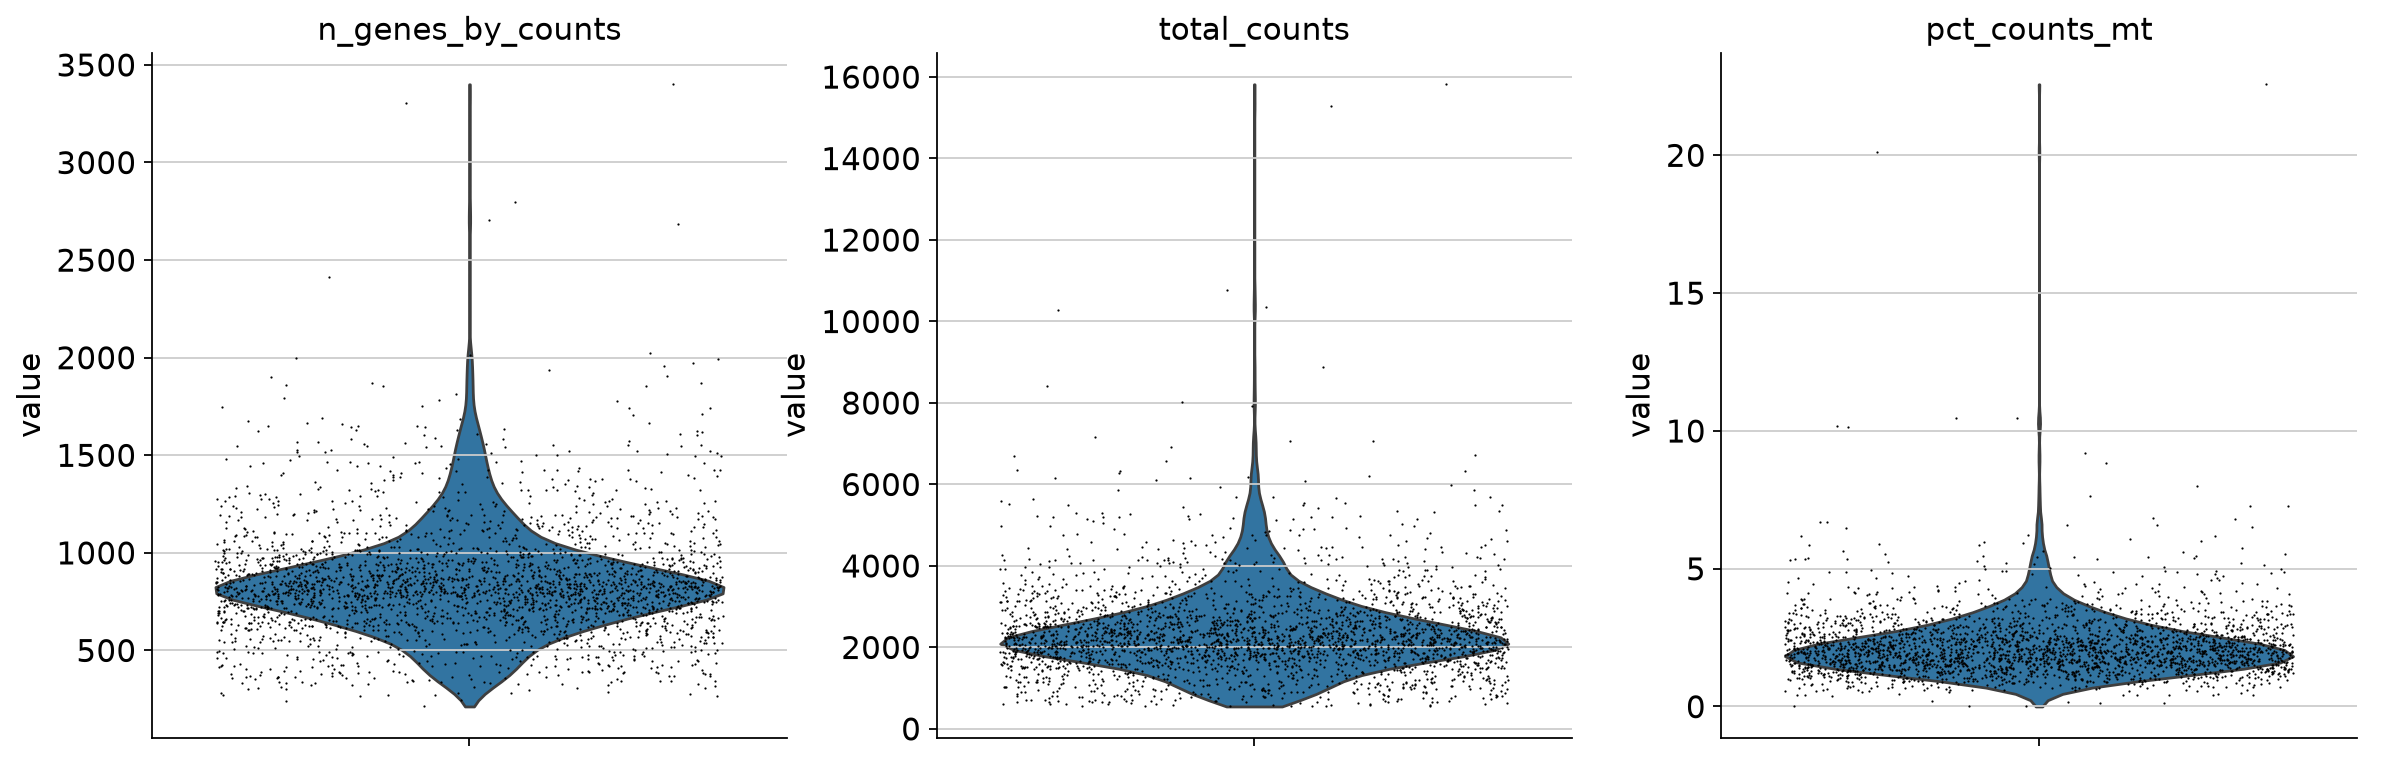

In [11]:
sc.pl.violin(
    adata, 
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4, multi_panel=True,
    save="_qc_matrics.png"
)

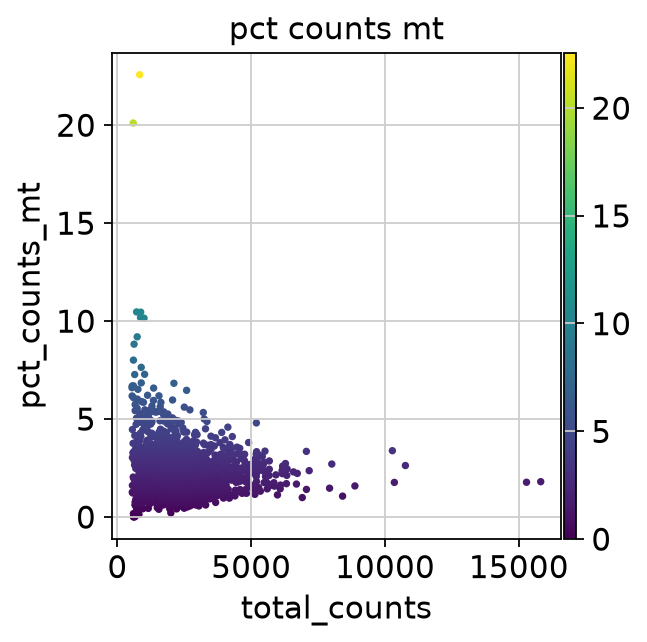

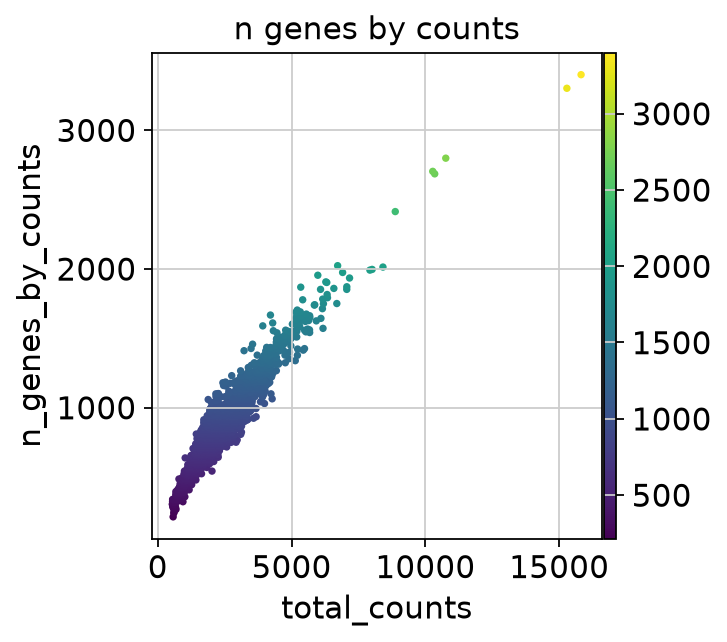

In [12]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", save="_mt.png", color = "pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", save="_genes.png", color = "n_genes_by_counts")

In [13]:
n_before = adata.n_obs
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
print("Cells before:", n_before)
print("Cells after QC:", adata.n_obs)
print("Removed:", n_before - adata.n_obs)

Cells before: 2700
Cells after QC: 2638
Removed: 62


In [14]:
import os
os.makedirs("../data/processed", exist_ok=True)
adata.write("../data/processed/pbmc_qc.h5ad")
print("Saved:", adata.shape)

Saved: (2638, 13714)


In [15]:
adata = sc.read_h5ad("../data/processed/pbmc_qc.h5ad")
print(adata.shape)

(2638, 13714)


In [16]:
adata.layers["counts"] = adata.X.copy()

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [18]:
sc.pp.log1p(adata)

In [19]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print("Highly variable genes:", adata.var.highly_variable.sum())

Highly variable genes: 1838


In [20]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()
print(adata.shape)

(2638, 1838)


In [21]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

In [22]:
adata.write("../data/processed/pbmc_normalized.h5ad")
print("Saved:", adata.shape)

Saved: (2638, 1838)


In [23]:
sc.tl.pca(adata, svd_solver="arpack")

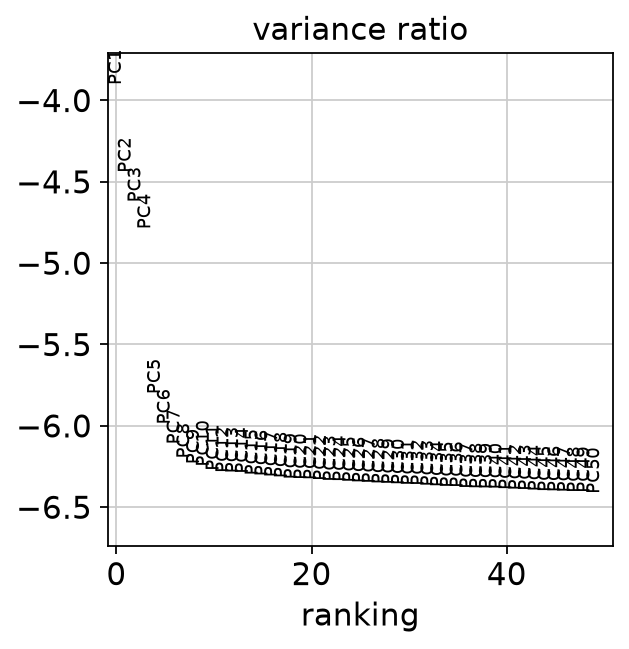

In [24]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [25]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

/home/ghashiamukhtar/.conda/envs/pbmc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
sc.tl.umap(adata)

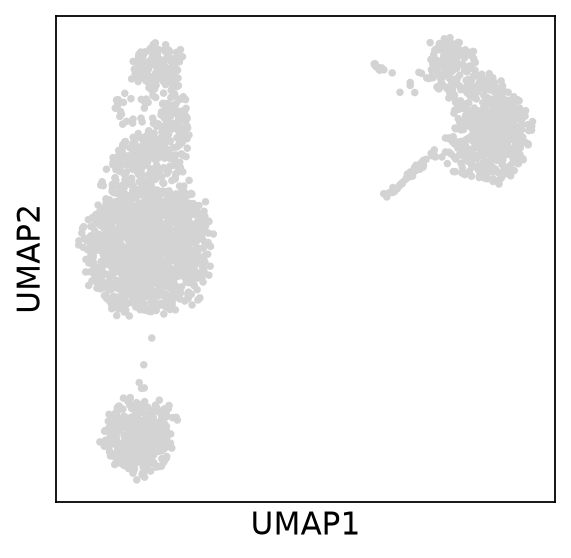

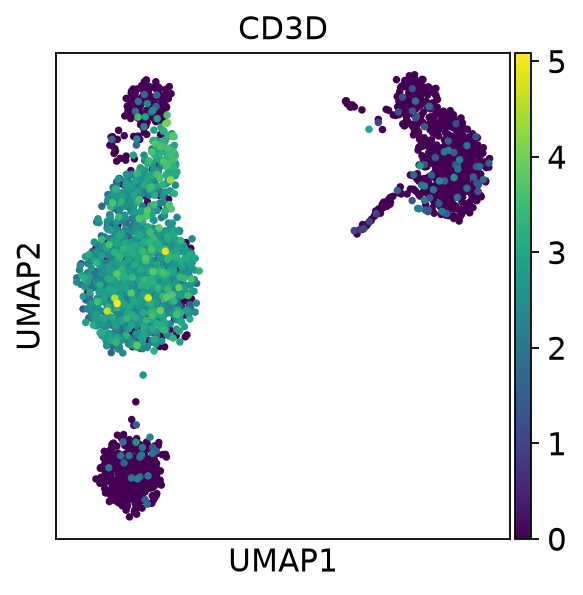

In [27]:
sc.pl.umap(adata, save="_raw.png")
sc.pl.umap(adata, color="CD3D", save="_CD3D.png")

In [28]:
adata.write("../data/processed/pbmc_umap.h5ad")
print("Saved:", adata.shape)

Saved: (2638, 1838)


In [29]:
sc.tl.leiden(
    adata,
    resolution=1.0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
print("Number of clusters:", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts().sort_index())

Number of clusters: 9
leiden
0    528
1    644
2    341
3    485
4    163
5    277
6    151
7     36
8     13
Name: count, dtype: int64


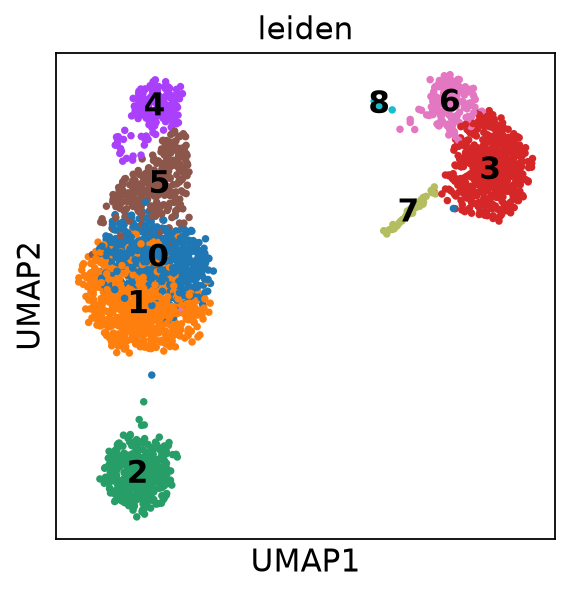

In [30]:
sc.pl.umap(adata, color="leiden", legend_loc="on data", save="_clusters.png")

In [31]:
for res in [0.25, 0.5, 1.0, 1.5]:
    sc.tl.leiden(adata, resolution=res, flavor="igraph", n_iterations=2,
                 directed=False, key_added=f"leiden_{res}")
    print(f"resolution={res}: {adata.obs[f'leiden_{res}'].nunique()} clusters")

resolution=0.25: 5 clusters
resolution=0.5: 6 clusters
resolution=1.0: 9 clusters
resolution=1.5: 14 clusters


In [32]:
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
print("Final:", adata.obs["leiden"].nunique(), "clusters")

Final: 9 clusters


In [33]:
adata.write("../data/processed/pbmc_clustered.h5ad")
print("Saved:", adata.shape)

Saved: (2638, 1838)


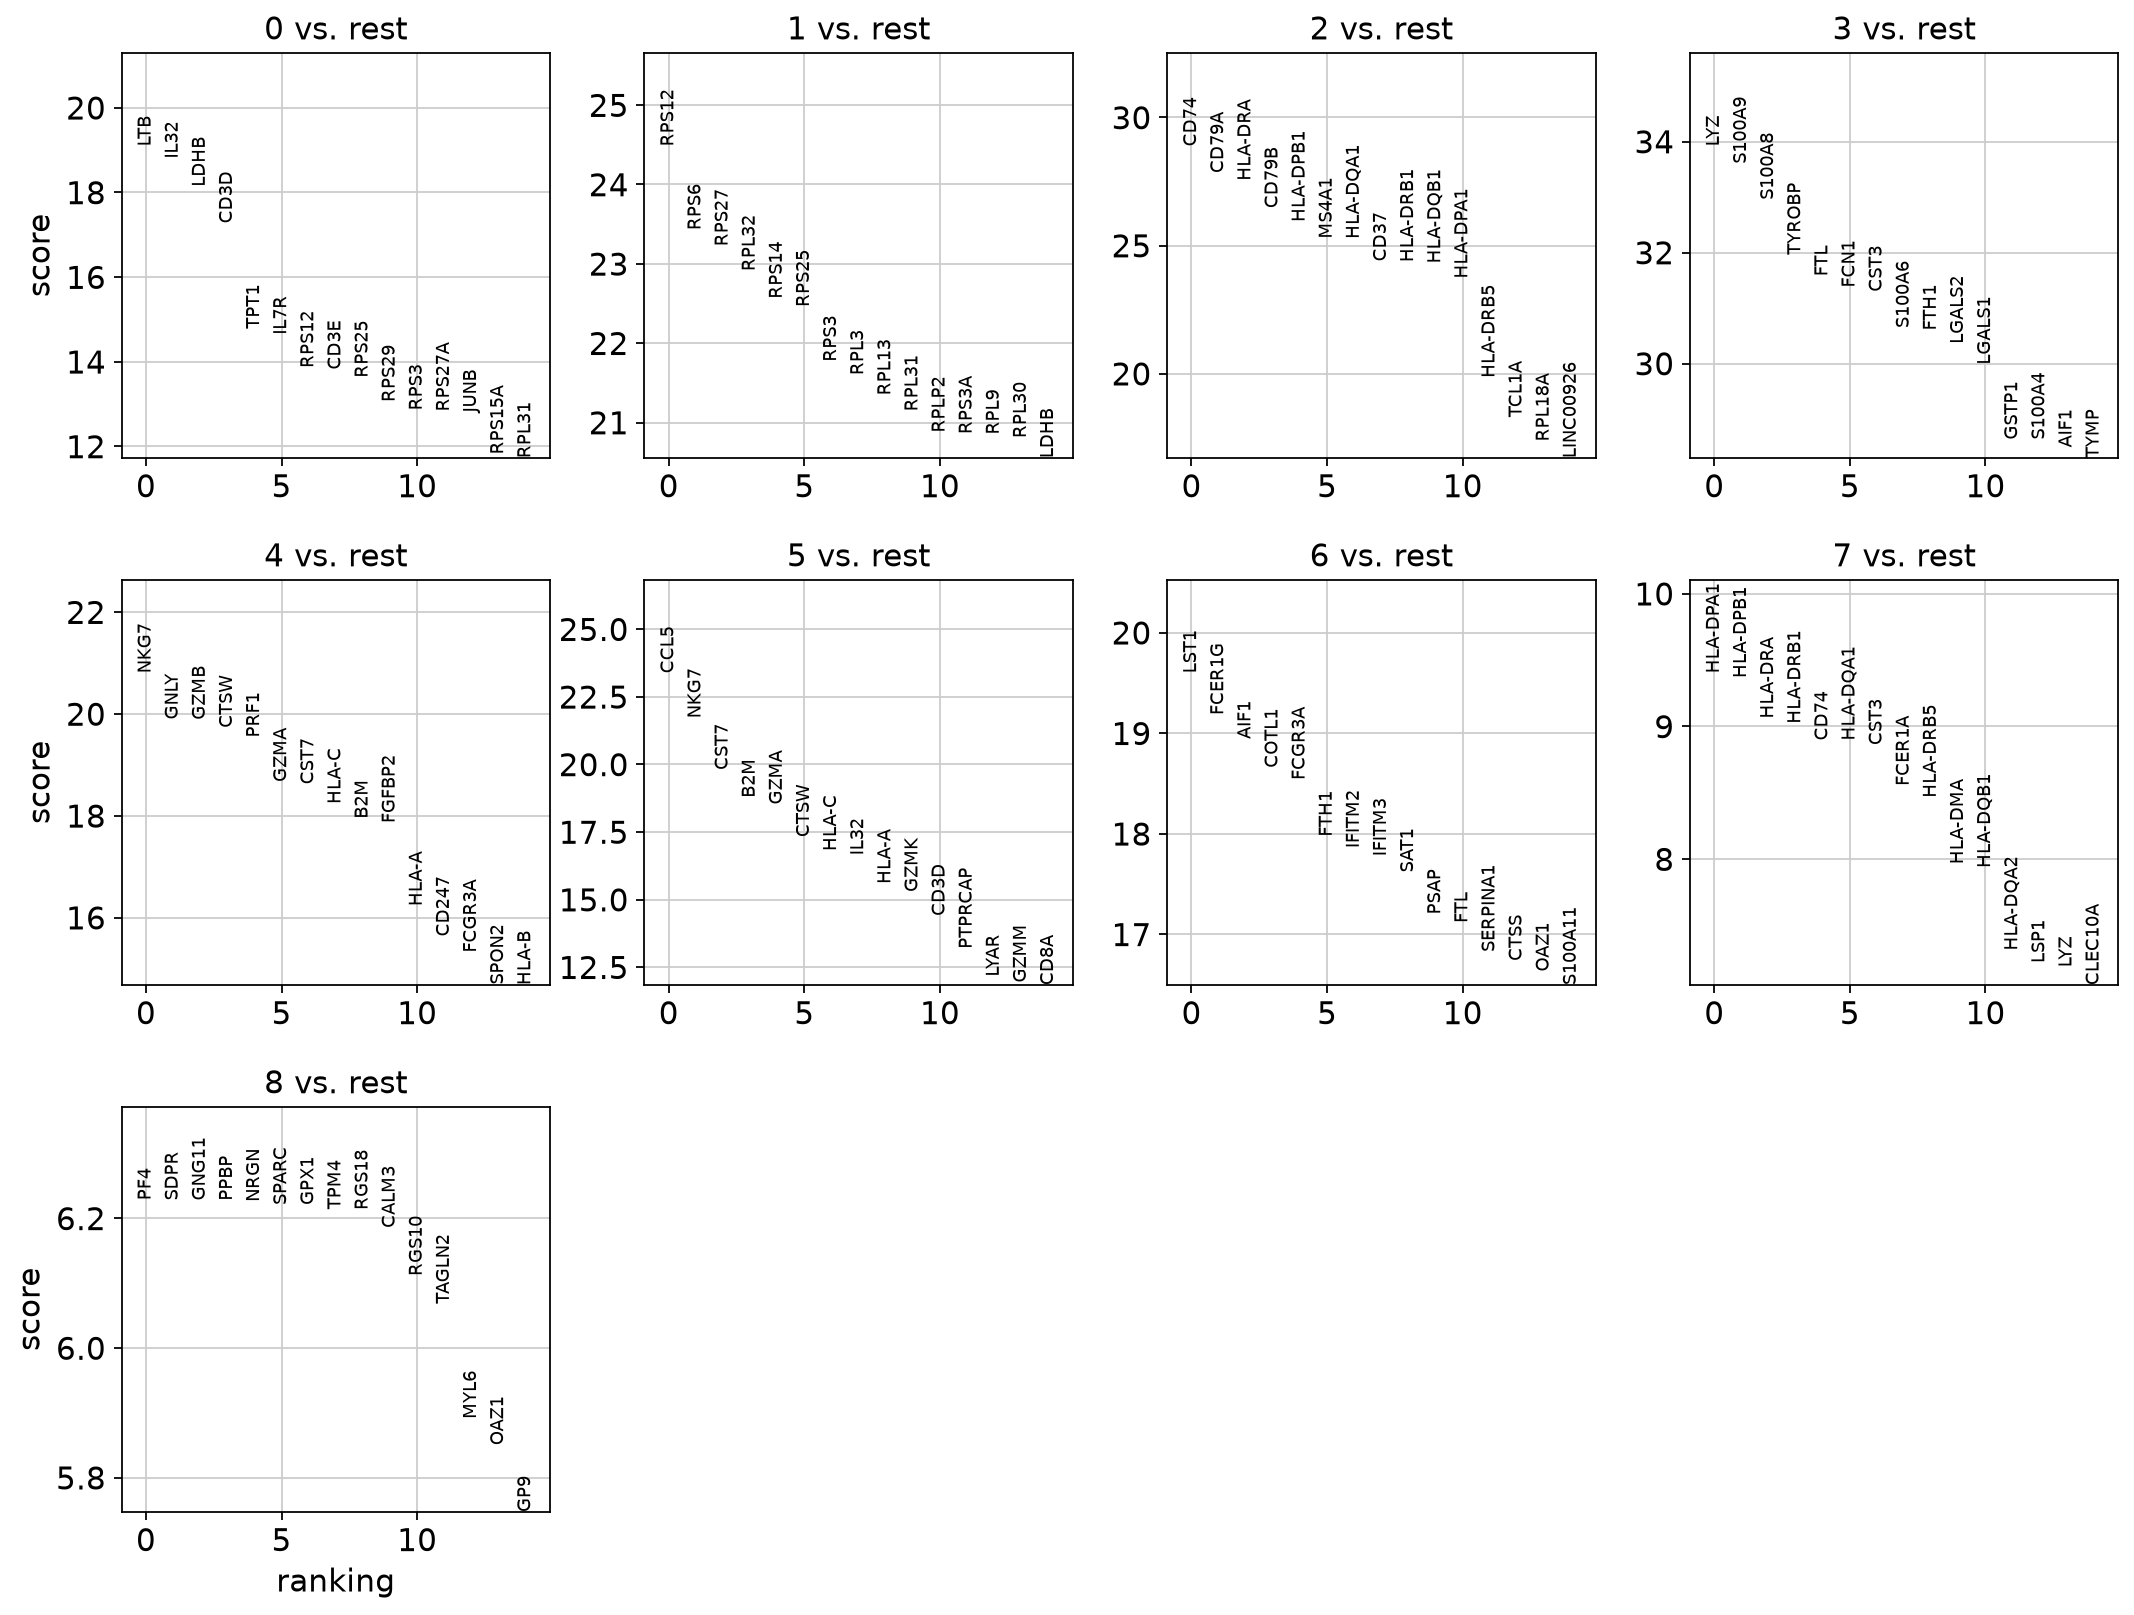

In [34]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False, save="_markers.png")

In [35]:
res = sc.get.rank_genes_groups_df(adata, group=None)
top = res.groupby("group", observed=True).head(8)
for grp in sorted(adata.obs["leiden"].unique().tolist(), key=int):
    print(grp, top[top.group==grp]["names"].tolist())

0 ['LTB', 'IL32', 'LDHB', 'CD3D', 'TPT1', 'IL7R', 'RPS12', 'CD3E']
1 ['RPS12', 'RPS6', 'RPS27', 'RPL32', 'RPS14', 'RPS25', 'RPS3', 'RPL3']
2 ['CD74', 'CD79A', 'HLA-DRA', 'CD79B', 'HLA-DPB1', 'MS4A1', 'HLA-DQA1', 'CD37']
3 ['LYZ', 'S100A9', 'S100A8', 'TYROBP', 'FTL', 'FCN1', 'CST3', 'S100A6']
4 ['NKG7', 'GNLY', 'GZMB', 'CTSW', 'PRF1', 'GZMA', 'CST7', 'HLA-C']
5 ['CCL5', 'NKG7', 'CST7', 'B2M', 'GZMA', 'CTSW', 'HLA-C', 'IL32']
6 ['LST1', 'FCER1G', 'AIF1', 'COTL1', 'FCGR3A', 'FTH1', 'IFITM2', 'IFITM3']
7 ['HLA-DPA1', 'HLA-DPB1', 'HLA-DRA', 'HLA-DRB1', 'CD74', 'HLA-DQA1', 'CST3', 'FCER1A']
8 ['PF4', 'SDPR', 'GNG11', 'PPBP', 'NRGN', 'SPARC', 'GPX1', 'TPM4']


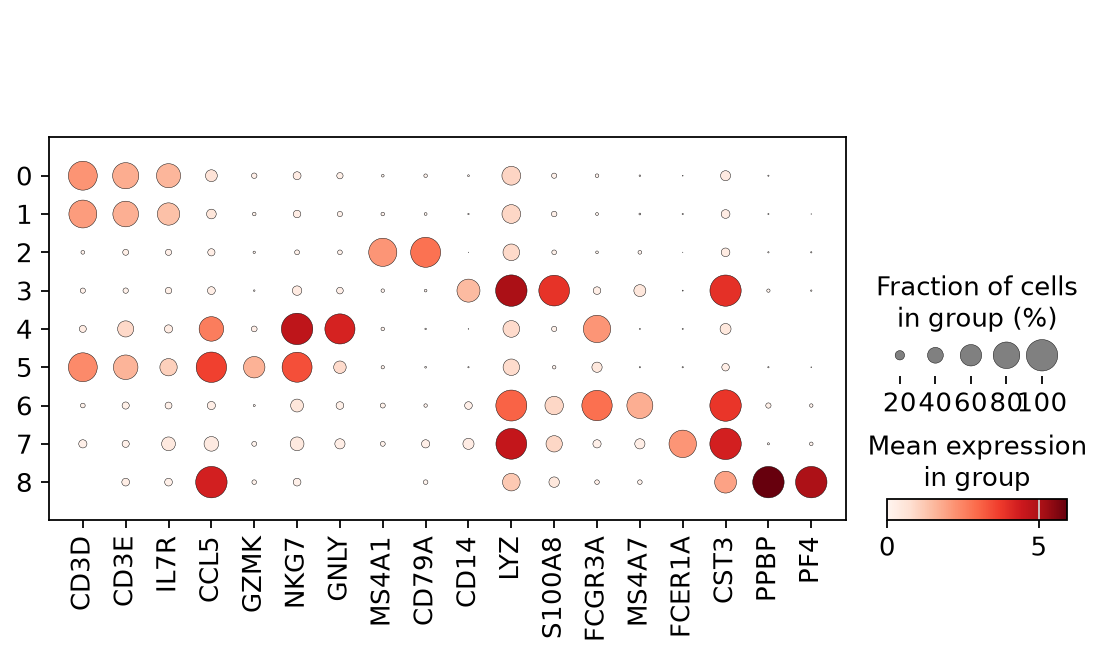

In [36]:
canonical = ["CD3D","CD3E","IL7R","CCL5","GZMK","NKG7","GNLY",
             "MS4A1","CD79A","CD14","LYZ","S100A8","FCGR3A","MS4A7",
             "FCER1A","CST3","PPBP","PF4"]
sc.pl.dotplot(adata, canonical, groupby="leiden", save="_canonical.png")

In [37]:
mapping = {
    "0": "CD4 T cells (memory)",   # LTB, IL32, CD3D, IL7R
    "1": "CD4 T cells (naive)",    # ribosomal-high, CD3D+
    "2": "B cells",                # CD79A, CD79B, MS4A1
    "3": "CD14+ Monocytes",        # LYZ, S100A8, S100A9, FCN1
    "4": "NK cells",               # GNLY, GZMB, PRF1, NKG7 (CD3-negative)
    "5": "CD8 T cells",            # CCL5, GZMA, CST7, NKG7 (CD3-positive)
    "6": "FCGR3A+ Monocytes",      # LST1, FCGR3A, AIF1
    "7": "Dendritic cells",        # FCER1A, CST3, HLA-DPA1
    "8": "Megakaryocytes",         # PF4, PPBP, SDPR
}
adata.obs["cell_type"] = adata.obs["leiden"].map(mapping).astype("category")
print(adata.obs["cell_type"].value_counts())

cell_type
CD4 T cells (naive)     644
CD4 T cells (memory)    528
CD14+ Monocytes         485
B cells                 341
CD8 T cells             277
NK cells                163
FCGR3A+ Monocytes       151
Dendritic cells          36
Megakaryocytes           13
Name: count, dtype: int64


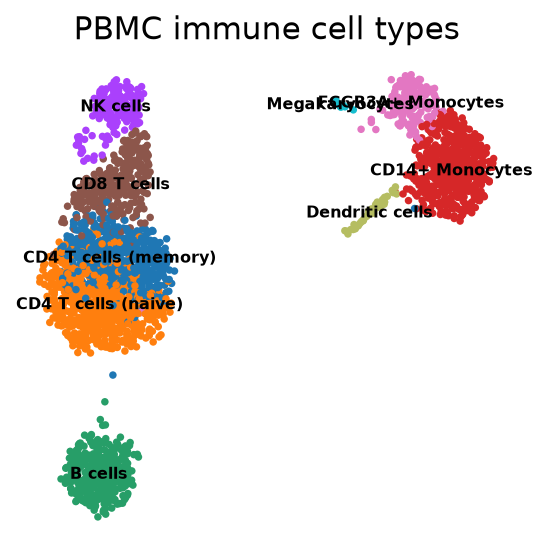

In [38]:
sc.pl.umap(adata, color="cell_type", legend_loc="on data",
           legend_fontsize=7, title="PBMC immune cell types",
           frameon=False, save="_annotated.png")

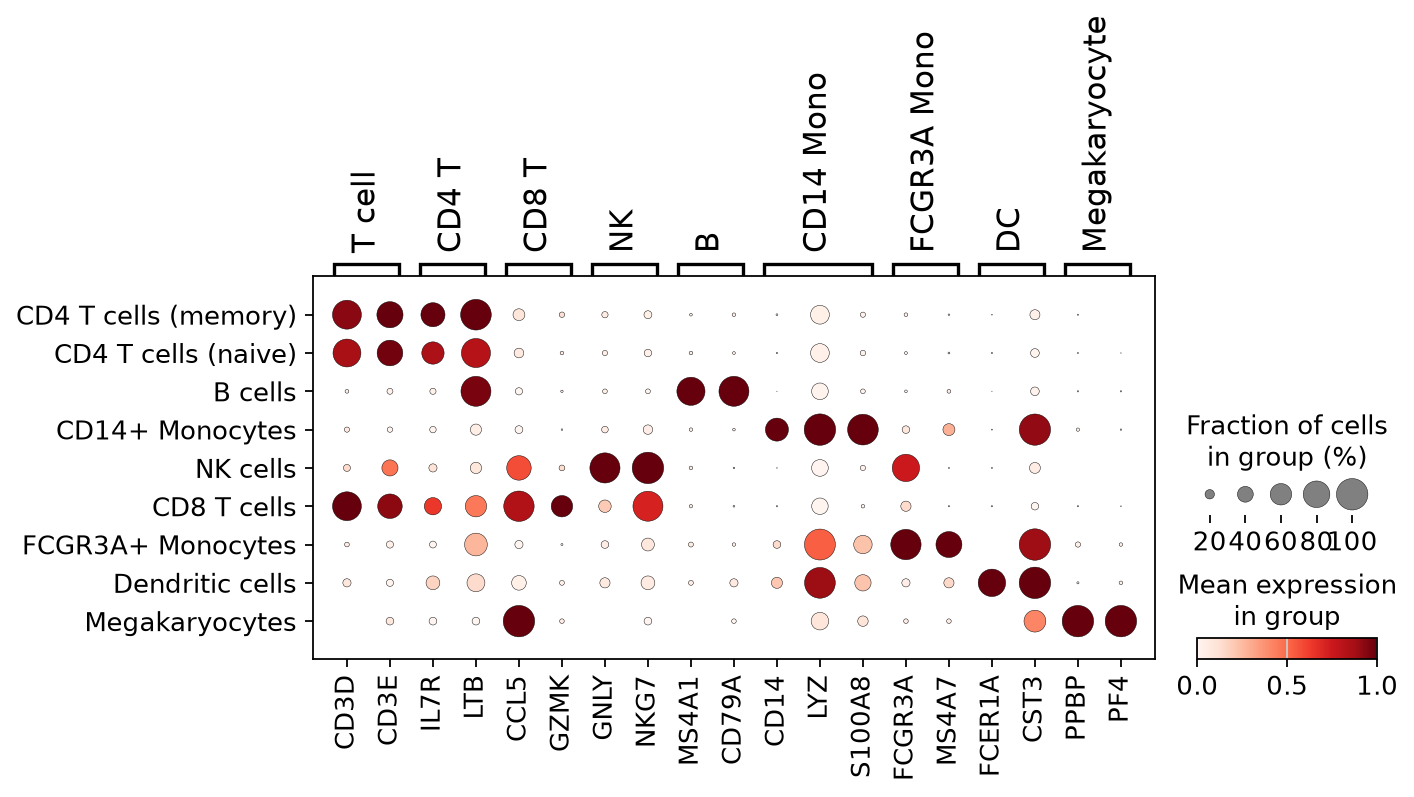

In [39]:
marker_genes = {
 "T cell": ["CD3D","CD3E"], "CD4 T": ["IL7R","LTB"], "CD8 T": ["CCL5","GZMK"],
 "NK": ["GNLY","NKG7"], "B": ["MS4A1","CD79A"],
 "CD14 Mono": ["CD14","LYZ","S100A8"], "FCGR3A Mono": ["FCGR3A","MS4A7"],
 "DC": ["FCER1A","CST3"], "Megakaryocyte": ["PPBP","PF4"],
}
sc.pl.dotplot(adata, marker_genes, groupby="cell_type",
              standard_scale="var", save="_final_dotplot.png")

In [40]:
adata.write("../data/processed/pbmc_annotated.h5ad")
print("Final object saved:", adata.shape)

Final object saved: (2638, 1838)


In [41]:
import os
os.makedirs("../results", exist_ok=True)          # create it if missing
res = sc.get.rank_genes_groups_df(adata, group=None)
res.to_csv("../results/marker_genes.csv", index=False)
print("saved", res.shape)

saved (123426, 6)


In [42]:
!ls figures/

dotplot__canonical.png		      scatter_mt.png	  umap_raw.png
dotplot__final_dotplot.png	      umap_annotated.png  violin_qc_matrics.png
rank_genes_groups_leiden_markers.png  umap_CD3D.png
scatter_genes.png		      umap_clusters.png


In [43]:
import shutil
import os
os.makedirs("../figures", exist_ok=True)
shutil.copy("figures/umap_annotated.png", "../figures/umap_annotated.png")
shutil.copy("figures/dotplot__final_dotplot.png",       "../figures/marker_dotplot.png")
print("done")

done
